In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import os
os.getcwd()

'/home/yagasri100'

In [10]:
dataframe = pd.read_csv(r'/home/yagasri100/Zomato-data-.csv')
dataframe.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
1,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
2,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
3,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
4,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet


In [13]:
dataframe = pd.read_csv("Zomato-data-.csv", header=1)
dataframe.columns = dataframe.columns.str.strip()  

print(dataframe.columns) 

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='str')


In [14]:
def handleRate(value):
    value = str(value).split('/')
    return float(value[0])

dataframe['rate'] = dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [15]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


In [16]:
print(dataframe.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


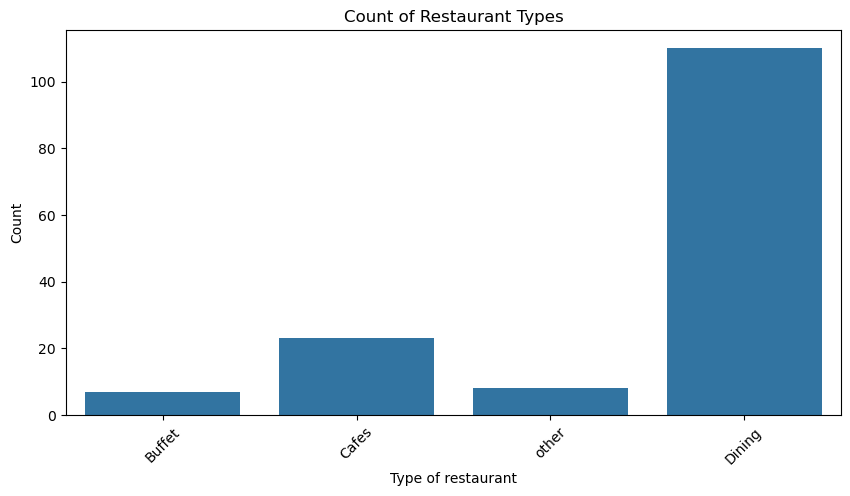

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("Type of restaurant")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Count of Restaurant Types")
plt.show()

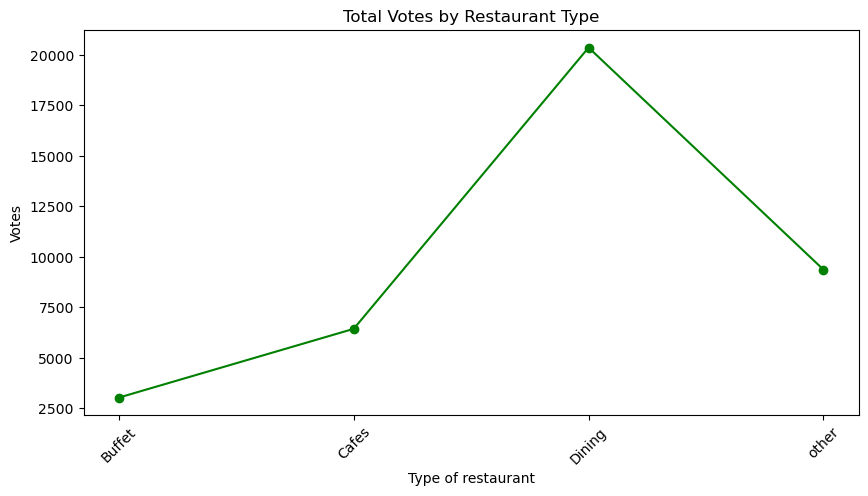

In [18]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes':grouped_data})
plt.figure(figsize=(10,5))
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')
plt.xticks(rotation=45)
plt.title("Total Votes by Restaurant Type")
plt.show()

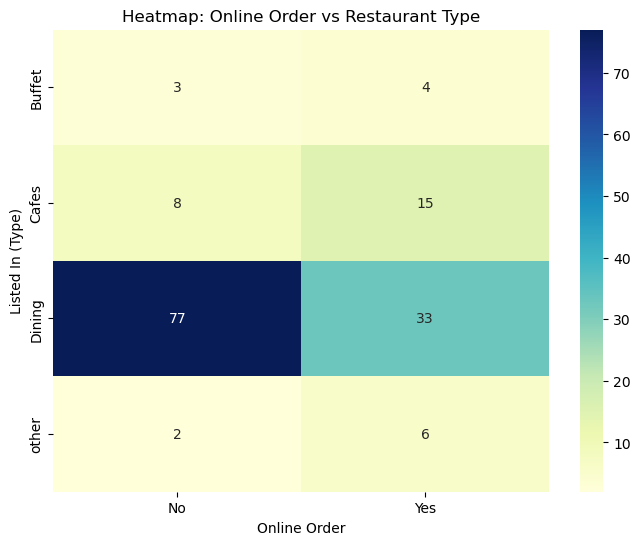

In [19]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap: Online Order vs Restaurant Type')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()